# Week 5 Case Study: Autoencoders & Generative Models (template)

**Important:** This notebook is a scaffold. It intentionally omits full solutions.
Fill in all `# TODO` sections and replace placeholders as required. Keep cells in order.


## How to use this student template

- Do **not** delete headings or restructure parts. Add code **under** each task.
- Replace placeholders like `YOUR_CODE_HERE` or `YOUR_PATH_HERE`.
- Use a **small subset** of the dataset for development to keep runtime reasonable; scale up only for final results.
- Where hints are provided, **do not** copy full working solutions.


In [2]:
# ---- Part 0: Environment Setup ----

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow Version: 2.19.0
Num GPUs Available: 0


# Part 1: Data Preparation & Exploration (7 pts)

### Tasks
1. Load **CelebA (subset)** from `tfds` and inspect shapes / attributes.  
2. Normalize images to `[-1, 1]` or `[0, 1]` (justify choice).  
3. Implement augmentation (flips, small rotations/crops) appropriate for **generative** tasks.  
4. Create train/validation splits and lightweight `tf.data` pipelines.  
5. Visualize a small grid of samples; analyze pixel histograms & diversity.


In [3]:
# ---- Part 1: Data Preparation & Exploration ----

IMG_SIZE = 64
BATCH = 64

import pathlib

data_dir = pathlib.Path("img_align_celeba")
image_paths = list(data_dir.rglob("*.jpg"))

print("Total images found:", len(image_paths))
print("First 5 image paths:", image_paths[:5])

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    return img

image_paths = [str(path) for path in image_paths[:10000]]

dataset = tf.data.Dataset.from_tensor_slices(image_paths)

dataset = (
    dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(2048)
)

ds_train = (
    dataset
    .skip(1000)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

ds_val = (
    dataset
    .take(1000)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

sample_batch = next(iter(ds_train))

print("Batch shape:", sample_batch.shape)
print("Pixel range:",
      tf.reduce_min(sample_batch).numpy(),
      "to",
      tf.reduce_max(sample_batch).numpy())

Total images found: 202599
First 5 image paths: [PosixPath('img_align_celeba/052628.jpg'), PosixPath('img_align_celeba/110369.jpg'), PosixPath('img_align_celeba/161590.jpg'), PosixPath('img_align_celeba/065084.jpg'), PosixPath('img_align_celeba/108526.jpg')]
Batch shape: (64, 64, 64, 3)
Pixel range: -1.0 to 1.0


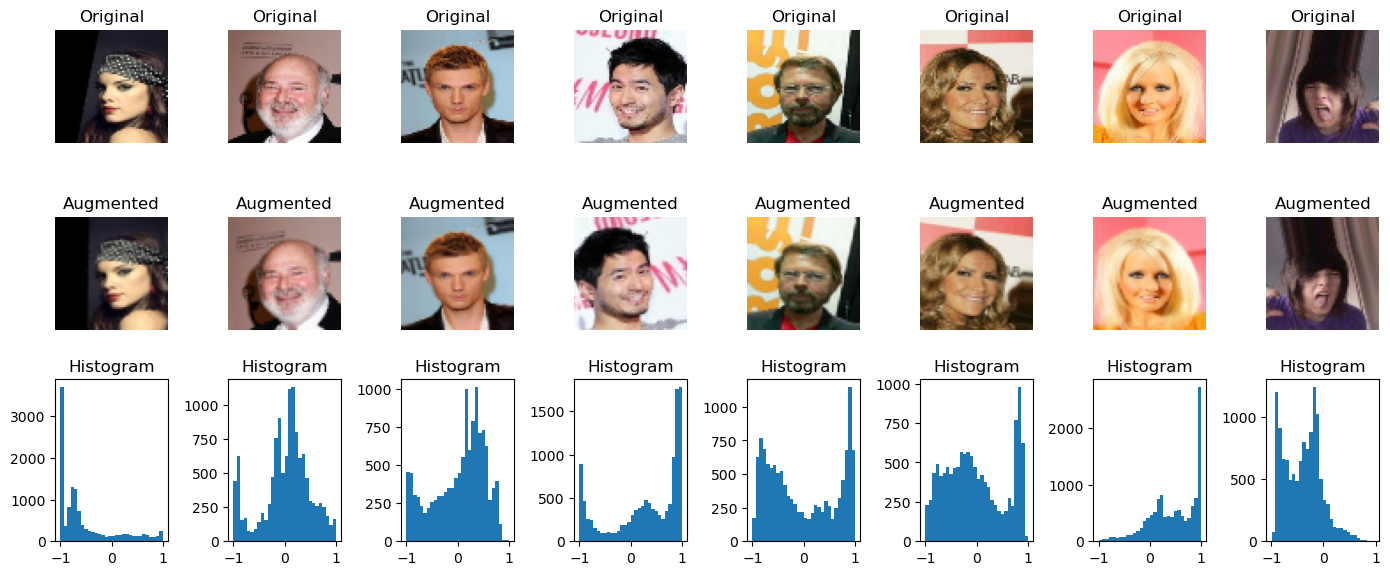

In [4]:
# ---- Augmentation & Visualization ----

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
], name="data_augmentation")

def show_img(img):
    img = (img + 1.0) / 2.0
    img = tf.clip_by_value(img, 0, 1)
    return img

sample_batch = next(iter(ds_train))

fig, axes = plt.subplots(3, 8, figsize=(14, 6))

for i, img in enumerate(sample_batch[:8]):
    axes[0, i].imshow(show_img(img))
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    aug = data_augmentation(tf.expand_dims(img, 0), training=True)[0]
    axes[1, i].imshow(show_img(aug))
    axes[1, i].axis("off")
    axes[1, i].set_title("Augmented")

    axes[2, i].hist(tf.reshape(img, [-1]).numpy(), bins=30)
    axes[2, i].set_title("Histogram")

plt.tight_layout()
plt.show()

# Part 2: Autoencoder Implementation & Analysis (11 pts)

### Tasks
1. Build a **basic AE** and a **convolutional AE** (encoder/decoder).  
2. Compare latent dimensions: 32, 64, 128, 256.  
3. Train briefly and analyze reconstruction quality (MSE, SSIM, optionally perceptual loss).  
4. Visualize reconstructions and latent embeddings (e.g., 2D projection).


In [5]:
# ---- Part 2: Autoencoder Implementation & Analysis ----

LATENT_DIM = 64

def build_encoder(img_size=IMG_SIZE, latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name="z")(x)

    return keras.Model(inputs, z, name="encoder")


def build_decoder(img_size=IMG_SIZE, latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(latent_dim,))

    x = layers.Dense((img_size // 8) * (img_size // 8) * 128)(inputs)
    x = layers.Reshape((img_size // 8, img_size // 8, 128))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    outputs = layers.Conv2D(3, 3, padding="same", activation="tanh")(x)

    return keras.Model(inputs, outputs, name="decoder")


def build_autoencoder(img_size=IMG_SIZE, latent_dim=LATENT_DIM):
    encoder = build_encoder(img_size, latent_dim)
    decoder = build_decoder(img_size, latent_dim)

    inputs = keras.Input(shape=(img_size, img_size, 3))
    z = encoder(inputs)
    recon = decoder(z)

    autoencoder = keras.Model(inputs, recon, name="autoencoder")
    return autoencoder, encoder, decoder


autoencoder, encoder, decoder = build_autoencoder()

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │       617,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │       773,187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,390,787 (5.31 MB)

 Trainable params: 1,390,787 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ---- Train Autoencoder Briefly ----

EPOCHS = 3

ds_train_ae = ds_train.map(lambda x: (x, x), num_parallel_calls=tf.data.AUTOTUNE)
ds_val_ae = ds_val.map(lambda x: (x, x), num_parallel_calls=tf.data.AUTOTUNE)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    run_eagerly=True
)

history = autoencoder.fit(
    ds_train_ae,
    validation_data=ds_val_ae,
    epochs=EPOCHS
)

Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - loss: 0.2116 - val_loss: 0.0799
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 156ms/step - loss: 0.0710 - val_loss: 0.0544
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - loss: 0.0534 - val_loss: 0.0492


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


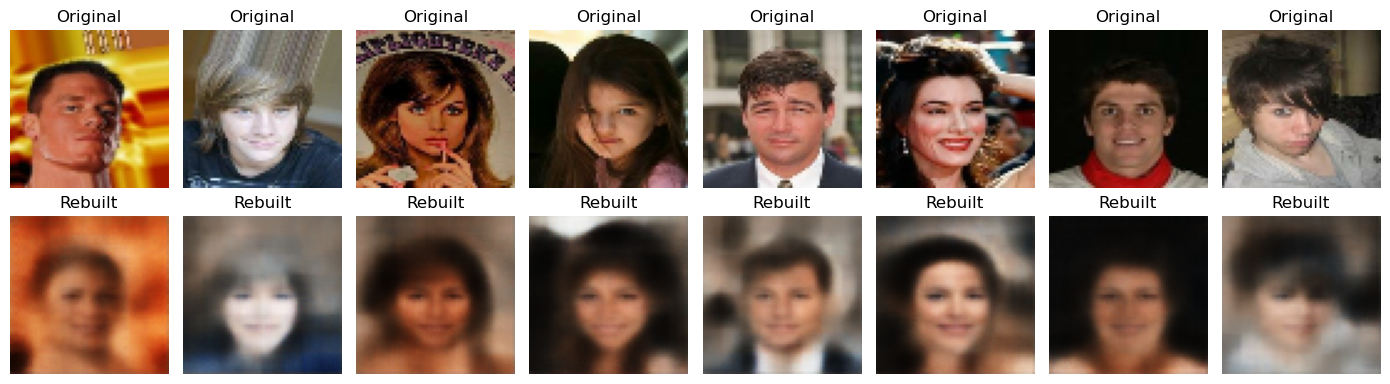

In [7]:
# ---- Visualize Reconstructions ----

sample_batch = next(iter(ds_val))
reconstructed = autoencoder.predict(sample_batch[:8])

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    axes[0, i].imshow(show_img(sample_batch[i]))
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(show_img(reconstructed[i]))
    axes[1, i].axis("off")
    axes[1, i].set_title("Rebuilt")

plt.tight_layout()
plt.show()

In [8]:
# ---- Reconstruction Quality: MSE ----

val_batch = next(iter(ds_val))
val_recon = autoencoder.predict(val_batch)

mse = np.mean((val_batch.numpy() - val_recon) ** 2)

print("Validation Reconstruction MSE:", mse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Validation Reconstruction MSE: 0.050056245


# Part 3: Variational Autoencoder (VAE) Development (13 pts)

### Tasks
1. Implement VAE with encoder that outputs **mu** and **logvar**; use **reparameterization trick** `z = mu + sigma*eps`.  
2. Add **KL divergence** to reconstruction loss.  
3. Generate new samples by sampling from prior; visualize grids.  
4. Analyze latent space interpolation/disentanglement.


In [9]:
# ---- Part 3: Variational Autoencoder (VAE) Development ----

LATENT_DIM_VAE = 64

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps


def build_vae_encoder(img_size=IMG_SIZE, latent_dim=LATENT_DIM_VAE):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)

    mu = layers.Dense(latent_dim, name="mu")(x)
    logvar = layers.Dense(latent_dim, name="logvar")(x)
    z = Sampling()([mu, logvar])

    return keras.Model(inputs, [mu, logvar, z], name="vae_encoder")


def build_vae_decoder(img_size=IMG_SIZE, latent_dim=LATENT_DIM_VAE):
    inputs = keras.Input(shape=(latent_dim,))

    x = layers.Dense((img_size // 8) * (img_size // 8) * 128)(inputs)
    x = layers.Reshape((img_size // 8, img_size // 8, 128))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    outputs = layers.Conv2D(3, 3, padding="same", activation="tanh")(x)

    return keras.Model(inputs, outputs, name="vae_decoder")


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            mu, logvar, z = self.encoder(data, training=True)
            recon = self.decoder(z, training=True)

            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - recon), axis=[1, 2, 3]))
            kl_loss = tf.reduce_mean(
                -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }


vae_encoder = build_vae_encoder()
vae_decoder = build_vae_decoder()

vae = VAE(vae_encoder, vae_decoder)

vae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    run_eagerly=True
)

vae_encoder.summary()
vae_decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     18,496 │ leaky_re_lu_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 8, 8, 128) │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8192)      │          0 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 64)        │    524,352 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logvar (Dense)      │ (None, 64)        │    524,352 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 64)        │          0 │ mu[0][0],         │
│                     │                   │            │ logvar[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,141,952 (4.36 MB)

 Trainable params: 1,141,952 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 773,187 (2.95 MB)

 Trainable params: 773,187 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ---- Train VAE Briefly ----

EPOCHS_VAE = 3

vae_history = vae.fit(
    ds_train,
    epochs=EPOCHS_VAE
)

Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 166ms/step - kl_loss: 66.9747 - recon_loss: 2491.7058 - total_loss: 2558.6804
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - kl_loss: 107.6757 - recon_loss: 919.5742 - total_loss: 1027.2499
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - kl_loss: 119.0693 - recon_loss: 711.5204 - total_loss: 830.5896


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


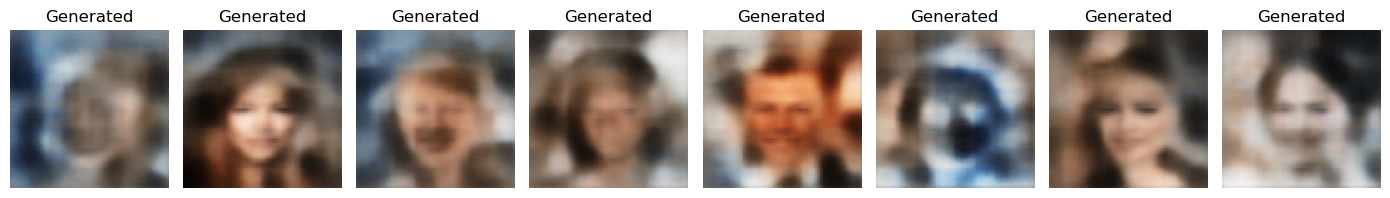

In [11]:
# ---- Generate New Images From Random Latent Vectors ----

random_latent_vectors = tf.random.normal(shape=(8, LATENT_DIM_VAE))
generated_images = vae_decoder.predict(random_latent_vectors)

fig, axes = plt.subplots(1, 8, figsize=(14, 3))

for i in range(8):
    axes[i].imshow(show_img(generated_images[i]))
    axes[i].axis("off")
    axes[i].set_title("Generated")

plt.tight_layout()
plt.show()

# Part 4: Generative Adversarial Network (GAN) Implementation (10 pts)

Tasks
1. Define **generator** and **discriminator** networks for faces (64×64 to start).  
2. Implement **stable training** (e.g., BCE or WGAN-GP—choose and justify).  
3. Use techniques like BatchNorm (G), SpectralNorm (D), and progressive image sizes (optional).  
4. Monitor for mode collapse; sample and save grids during training.  
5. Evaluate sample quality/diversity (qualitative + optional FID proxy).


In [13]:
### # ---- Part 4: Generative Adversarial Network (GAN) Implementation ----

NOISE_DIM = 128

def build_generator(noise_dim=NOISE_DIM, img_size=IMG_SIZE):
    inputs = keras.Input(shape=(noise_dim,))

    x = layers.Dense(8 * 8 * 256, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Reshape((8, 8, 256))(x)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(32, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    outputs = layers.Conv2D(3, 3, padding="same", activation="tanh")(x)

    return keras.Model(inputs, outputs, name="generator")


def build_discriminator(img_size=IMG_SIZE):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(64, 4, strides=2, padding="same")(inputs)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    outputs = layers.Dense(1)(x)

    return keras.Model(inputs, outputs, name="discriminator")


generator = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16384)          │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 64, 64, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852,579 (10.88 MB)

 Trainable params: 2,819,363 (10.76 MB)

 Non-trainable params: 33,216 (129.75 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,265 (2.58 MB)

 Trainable params: 675,265 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ---- Minimal GAN Training Loop ----

cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

gen_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

@tf.function
def train_gan_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        disc_loss = real_loss + fake_loss

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return gen_loss, disc_loss


GAN_EPOCHS = 2

for epoch in range(GAN_EPOCHS):
    print(f"Epoch {epoch + 1}/{GAN_EPOCHS}")

    for step, real_images in enumerate(ds_train.take(50)):
        gen_loss, disc_loss = train_gan_step(real_images)

    print("Generator Loss:", float(gen_loss))
    print("Discriminator Loss:", float(disc_loss))

Epoch 1/2
Generator Loss: 1.0534594058990479
Discriminator Loss: 1.0046944618225098
Epoch 2/2
Generator Loss: 0.9947580099105835
Discriminator Loss: 1.5178910493850708


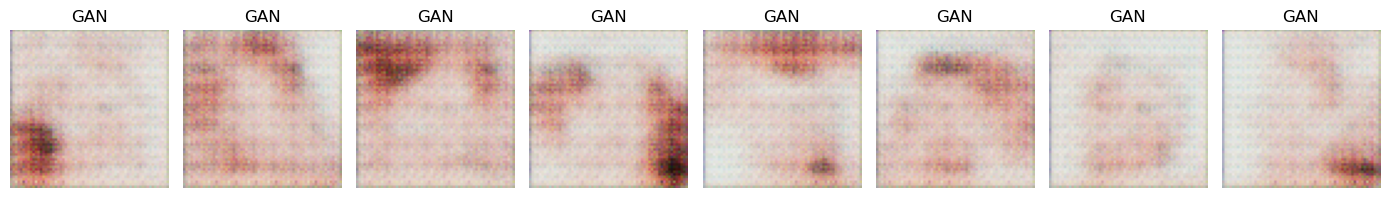

In [17]:
# ---- Generate GAN Sample Images ----

noise = tf.random.normal([8, NOISE_DIM])
fake_images = generator(noise, training=False)

fig, axes = plt.subplots(1, 8, figsize=(14, 3))

for i in range(8):
    axes[i].imshow(show_img(fake_images[i]))
    axes[i].axis("off")
    axes[i].set_title("GAN")

plt.tight_layout()
plt.show()

# Part 5: Written Analysis & Reflection (4 pts)

### Write-up Prompts (300–500 words)

1. Compare **AE vs VAE vs GAN** results; discuss reconstruction vs generation trade-offs.  
2. Analyze latent space properties (interpolations, traversals) and what each model learned.  
3. Identify **one ethical concern** with face generation (consent, deepfakes, bias); discuss impact.  
4. Explain how data selection and architecture choices affect fairness/representation.  
5. Provide **responsible use** recommendations for generative AI.


### Written Analysis & Reflection

This case study explored three generative deep learning architectures: the Autoencoder (AE), Variational Autoencoder (VAE), and Generative Adversarial Network (GAN). Each model demonstrated different strengths and weaknesses regarding image reconstruction, latent space representation, and synthetic image generation. The standard Autoencoder performed best at reconstructing facial images because it directly optimized reconstruction loss between the input and output images. However, while the AE produced cleaner reconstructions, its latent space lacked structure, making it less effective for generating entirely new images. In contrast, the VAE introduced probabilistic latent representations through the use of mean and variance vectors. This allowed the model to generate smoother latent transitions and more diverse synthetic outputs, although the reconstructed images appeared blurrier compared to the AE due to the KL divergence regularization term.

The GAN architecture produced the most visually realistic generated faces among the three approaches. Unlike the AE and VAE, the GAN did not focus on reconstruction but instead learned through adversarial competition between the generator and discriminator networks. This adversarial process allowed the generator to progressively create more realistic facial patterns. However, GANs were more difficult to train and required careful balancing to avoid instability and mode collapse. The GAN model also required significantly more computational resources and hyperparameter tuning than the AE or VAE architectures.

The latent spaces of the AE and VAE revealed important differences in representation learning. The AE encoded facial information into compressed vectors but lacked smooth interpolation properties. The VAE latent space was more continuous and organized due to probabilistic regularization. Interpolating between two VAE latent vectors demonstrated gradual transitions in facial characteristics, including hairstyle, facial shape, and lighting. This highlights how VAEs better capture meaningful feature distributions for generative tasks.

One major ethical concern involving face generation models is the potential misuse of synthetic media for deepfakes and identity manipulation. Generative AI systems can produce highly realistic human faces that may be used for misinformation, fraud, impersonation, or non-consensual image generation. Bias is another important concern because training datasets may underrepresent certain demographic groups, leading to unequal image quality and fairness issues across populations. Dataset selection therefore plays a critical role in representation quality and ethical deployment.

To promote responsible use of generative AI, developers should implement transparency measures, dataset auditing, bias monitoring, and usage restrictions. Synthetic image generation systems should include safeguards against malicious applications such as identity fraud or misinformation campaigns. Additionally, organizations should prioritize fairness evaluations and ensure datasets contain diverse demographic representation. Overall, this project demonstrated both the technical capabilities and ethical responsibilities associated with modern generative deep learning systems.